In [ ]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 75.0 MB/s eta 0:00:00


In [ ]:
!pip install s3fs h5netcdf --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 87.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.3.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.3.0 which is incompatible.


In [ ]:
!pip install arm-pyart

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.8/145.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 1.7 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os, sys, glob
import numpy as np
import csv
import json
from netCDF4 import Dataset
import cartopy.crs as ccrs
import pyart
from pyart.testing import get_test_data
import fsspec
import xarray as xr
import s3fs
import h5py


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [ ]:
cd prj_files/

/content/prj_files


In [ ]:
# Opens and reads data from csv file
data_file = "storm_data_search_results.csv"
columns = ['EVENT_ID','CZ_NAME_STR','BEGIN_LOCATION','BEGIN_DATE','BEGIN_TIME','EVENT_TYPE','MAGNITUDE','TOR_F_SCALE','DEATHS_DIRECT','INJURIES_DIRECT','DAMAGE_PROPERTY_NUM','DAMAGE_CROPS_NUM','STATE_ABBR','CZ_TIMEZONE','MAGNITUDE_TYPE','EPISODE_ID','CZ_TYPE','CZ_FIPS','WFO','INJURIES_INDIRECT','DEATHS_INDIRECT','SOURCE','FLOOD_CAUSE','TOR_LENGTH','TOR_WIDTH','BEGIN_RANGE','BEGIN_AZIMUTH','END_RANGE','END_AZIMUTH','END_LOCATION','END_DATE','END_TIME','BEGIN_LAT','BEGIN_LON','END_LAT','END_LON','EVENT_NARRATIVE','EPISODE_NARRATIVE','ABSOLUTE_ROWNUMBER']
data = pd.read_csv(data_file, header=0, names=columns)

# Defines variables from csv file to be used later
b_lat = data['BEGIN_LAT']
b_lon = data['BEGIN_LON']
e_lat = data['END_LAT']
e_lon = data['END_LON']
f_scale = data['TOR_F_SCALE']
row = data['ABSOLUTE_ROWNUMBER']

(-92.0, -87.0)

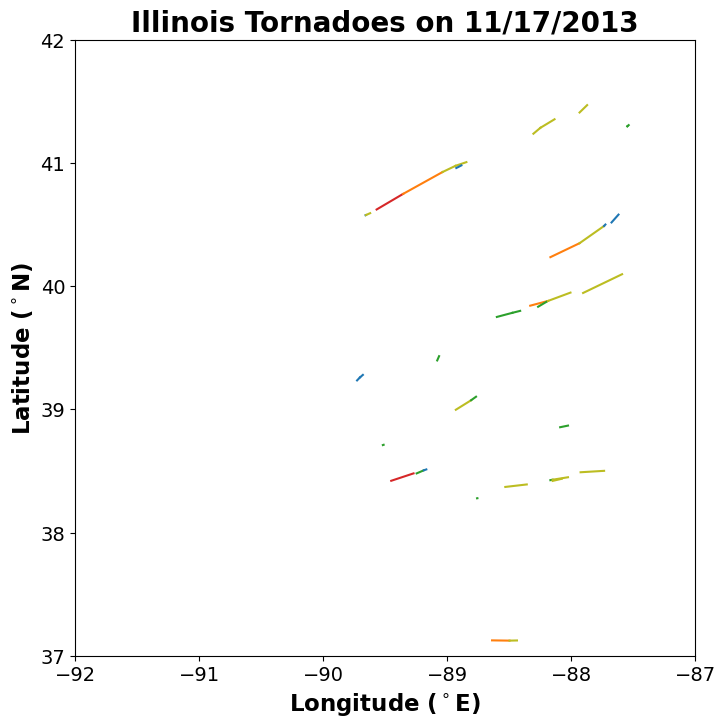

In [ ]:
fig = plt.figure(figsize=(8,8))
# Defines colors for each EF-scale value, remember to switch EF to F for pre-2007 events (eg. EF0 to F0)
use_colors = {"EFU": "tab:gray", "EF0": "tab:blue", "EF1": "tab:green", "EF2": "tab:olive", "EF3": "tab:orange", "EF4": "tab:red", "EF5": "tab:purple"}

for i in range(len(f_scale)):
  # Skip plotting if any coordinate values are NaN
  if pd.isna(b_lat.iloc[i]) or pd.isna(b_lon.iloc[i]) or pd.isna(e_lat.iloc[i]) or pd.isna(e_lon.iloc[i]):
    continue
  plt.plot([b_lon.iloc[i], e_lon.iloc[i]], [b_lat.iloc[i], e_lat.iloc[i]], color=use_colors[f_scale.iloc[i]]) # iloc needed here to define each variable's location in csv file
    # use_colors variable here uses f_scale variable defined previously to color each tornado path

plt.title("Illinois Tornadoes on 11/17/2013", fontsize='20', fontweight='bold')
plt.xlabel('Longitude ($^\circ$E)',fontsize=16.5,fontweight='bold')
plt.ylabel('Latitude ($^\circ$N)',fontsize=16.5,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(37, 42)
plt.xlim(-92, -87)